In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# The second law decides how much a fermenter can make (Illustrations 15.7-6 to 15.7-11, Figures 15.7-2, 15.7-3 and 15.7-5)

$$Y_{Q/S}=Y_{B/S}\Delta_cH_B+Y_{P/S}\Delta_cH_P-\Delta_cH_S-Y_{N/S}\Delta_cH_N$$
$$\Delta_cG_S+Y_{N/S}\Delta_cG_N\ \ge\ Y_{B/S}\Delta_cG_B+Y_{P/S}\Delta_cG_P$$

The atom balances of the previous notebook give what *can* come out of a fermenter if the yield
factors are known. This one says which yield factors are possible at all.

Two things make it work. The first is that heats of **combustion** replace heats of formation, so
that the reference state is CO$_2$, liquid water and N$_2$ rather than the elements — which is what
lets a calorimeter measure the properties of a substance nobody can write a formula for. The second
is that the same combination $\xi_S+\xi_NY_{N/S}-\xi_BY_{B/S}-\xi_PY_{P/S}$ appears in the oxygen
balance, in the energy balance and in the second-law constraint. Set it $\ge 0$ and three conclusions
follow at once, without solving anything:

$$Y_{O_2/S}\ge 0\qquad Y_{Q/S}\le 0 \qquad Y_{Q/S}=-443.6\,Y_{O_2/S}$$

A fermentation can only consume oxygen, it is always exothermic, and the heat released is
proportional to the oxygen used. The last of the three has been measured in the laboratory — and
holds across the animal kingdom too, over a millionfold range of body weight.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:
import sys; sys.path.insert(0, "..")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from thermo.bioreactor import (CMole, Fermentation, from_table, metabolic_rate,
                               REGULARITY_G, REGULARITY_H)
from thermo.charts import use_book_style

use_book_style()
os.makedirs("pdf", exist_ok=True)
FIG_W = 3.4
T25 = 298.15

glucose = from_table("glucose")
ethanol = from_table("ethanol")
ammonia = from_table("ammonia")
BIOMASS_ROELS = CMole("CH1.8O0.5N0.2", name="Roels average biomass")
print(f"  {glucose}\n  {ethanol}\n  {ammonia}\n  {BIOMASS_ROELS}")
print(f"\n  energy regularity: dcG = {REGULARITY_G} xi,  dcH = {REGULARITY_H} xi "
      f"kJ per C-mole")

  CMole(CH2O (glucose), xi = 4)
  CMole(CH3O0.5 (ethanol), xi = 6)
  CMole(NH3 (ammonia), xi = 3)
  CMole(CH1.8O0.5N0.2 (Roels average biomass), xi = 4.8)

  energy regularity: dcG = 112.0 xi,  dcH = 110.9 xi kJ per C-mole


## Illustration 15.7-6 — the heat load, two ways

*S. cerevisiae* aerobically: $Y_{B/S}=0.235$ of biomass $\mathrm{CH_{1.8}O_{0.56}N_{0.17}}$,
$Y_{P/S}=0.451$ ethanol, $Y_{N/S}=0.0399$ ammonia, all per C-mole of glucose.

Everything has a measured heat of combustion except the biomass, so Eq. 15.7-10 supplies that one.
The Note then asks what happens if the regularity estimate is used for *everything*, and the
difference — 51.0 against 34.8 kJ — turns out to be almost entirely glucose's error, not the
biomass's.

In [3]:
yeast = CMole("CH1.8O0.56N0.17", name="S. cerevisiae, aerobic")
f6 = Fermentation(substrate=glucose, biomass=yeast, nitrogen=ammonia, product=ethanol)
YB, YP, YN = 0.235, 0.451, 0.0399

print(f"  xi(biomass) = 4 x 1 + 1.8 - 2 x 0.56 = {yeast.xi:.2f}      printed 4.68")
print(f"  dcH(biomass) = 110.9 x {yeast.xi:.2f} = {yeast.combustion_H():.1f} kJ/C-mole"
      f"      printed 519.0")

Q_measured = f6.heat_load(YB, YP, YN)
Q_regular = f6.heat_load_regularity(YB, YP, YN)
print(f"\n  Y_Q/S, measured dcH where available = {Q_measured:+.1f} kJ   printed -51.0")
print(f"  Y_Q/S, energy regularity throughout = {Q_regular:+.1f} kJ   printed -34.8")
assert abs(Q_measured + 51.0) < 0.1 and abs(Q_regular + 34.8) < 0.1

gap_glucose = glucose.combustion_H() - REGULARITY_H * glucose.xi
gap_ethanol = ethanol.combustion_H() - REGULARITY_H * ethanol.xi
gap_ammonia = ammonia.combustion_H() - REGULARITY_H * ammonia.xi
# Each species enters Y_Q/S with the sign it has in Eq. 15.7-8b, so the SUBSTRATE and
# the nitrogen source contribute MINUS their departure from the correlation.
contrib = {"glucose (substrate, enters negative)": -gap_glucose,
           "ethanol (product, enters positive)": YP * gap_ethanol,
           "ammonia (N source, enters negative)": -YN * gap_ammonia,
           "biomass (regularity in both, so nothing)": 0.0}
print(f"\n  where the {Q_measured - Q_regular:+.1f} kJ difference comes from:")
for label, v in contrib.items():
    print(f"    {label:42s} {v:+7.1f} kJ")
print(f"    {'total':42s} {sum(contrib.values()):+7.1f} kJ, against "
      f"{Q_measured - Q_regular:+.1f} above")
assert abs(sum(contrib.values()) - (Q_measured - Q_regular)) < 1e-9
print("\n  The Note attributes the difference to glucose, and it is right: glucose is")
print("  24.2 kJ/C-mole above the correlation and everything else together gives back")
print("  only 8.0 of it.")

  xi(biomass) = 4 x 1 + 1.8 - 2 x 0.56 = 4.68      printed 4.68
  dcH(biomass) = 110.9 x 4.68 = 519.0 kJ/C-mole      printed 519.0

  Y_Q/S, measured dcH where available = -51.0 kJ   printed -51.0
  Y_Q/S, energy regularity throughout = -34.8 kJ   printed -34.8

  where the -16.2 kJ difference comes from:
    glucose (substrate, enters negative)         -24.2 kJ
    ethanol (product, enters positive)            +8.6 kJ
    ammonia (N source, enters negative)           -0.6 kJ
    biomass (regularity in both, so nothing)      +0.0 kJ
    total                                        -16.2 kJ, against -16.2 above

  The Note attributes the difference to glucose, and it is right: glucose is
  24.2 kJ/C-mole above the correlation and everything else together gives back
  only 8.0 of it.


One thing to fix in passing: the illustration's Solution line reads *"the heat of combustion of ammonia is 383.0 kJ/mol"*, and Table 15.7-2 gives **348.1**. The arithmetic on the next line uses
348.1, so 383.0 is a transposition.

In [4]:
for value in (348.1, 383.0):
    q = (YB * yeast.combustion_H() + YP * ethanol.combustion_H()
         - glucose.combustion_H() - YN * value)
    print(f"  with dcH(ammonia) = {value:5.1f}:  Y_Q/S = {q:+.2f} kJ"
          + ("   <- the printed answer" if abs(q + 51.0) < 0.1 else ""))

  with dcH(ammonia) = 348.1:  Y_Q/S = -51.01 kJ   <- the printed answer
  with dcH(ammonia) = 383.0:  Y_Q/S = -52.40 kJ


## Illustration 15.7-7 — is this fermentation even allowed?

$$\Delta_cG_S+Y_{N/S}\Delta_cG_N\ \ge\ Y_{B/S}\Delta_cG_B+Y_{P/S}\Delta_cG_P$$

The constraint has a one-line reading: **the Gibbs energy going in has to be at least the Gibbs
energy coming out.** What is left over went into entropy generation, which is where the "efficiency"
of the last column comes from.

In [5]:
c = f6.second_law(YB, YP, YN)
print(f"  {c.available:.1f} >= {c.required:.1f} kJ      printed 494.3 > 420.6")
print(f"  efficiency {100 * c.efficiency:.1f} percent   printed 85.1")
assert abs(c.available - 494.3) < 0.1 and abs(c.required - 420.6) < 0.1

cr = f6.second_law_regularity(YB, YP, YN)
print(f"\n  the Note, on degrees of reduction alone:")
print(f"  {cr.available:.4f} > {cr.required:.4f}      printed 4.1197 > 3.8058")
print(f"  efficiency {100 * cr.efficiency:.1f} percent   printed 92.4")
assert abs(cr.available - 4.1197) < 1e-3 and abs(cr.required - 3.8058) < 1e-3
print("\n  Same conclusion, 7 points apart in the efficiency -- which is what the")
print("  energy regularity approximation costs when it is applied to the substrate")
print("  as well as to the biomass.")

  494.3 >= 420.6 kJ      printed 494.3 > 420.6
  efficiency 85.1 percent   printed 85.1

  the Note, on degrees of reduction alone:
  4.1197 > 3.8058      printed 4.1197 > 3.8058
  efficiency 92.4 percent   printed 92.4

  Same conclusion, 7 points apart in the efficiency -- which is what the
  energy regularity approximation costs when it is applied to the substrate
  as well as to the biomass.


## Illustration 15.7-8 — the anaerobic case, and a printed sum that does not add

Illustration 15.7-3's anaerobic numbers, put through the energy balance and the second-law
constraint. Both come out; one of the printed intermediate sums does not.

In [6]:
f8 = Fermentation(substrate=glucose, biomass=BIOMASS_ROELS,
                  nitrogen=ammonia, product=ethanol)
YB8, YP8, YN8 = 0.14, 0.569, 0.028

Q8 = f8.heat_load(YB8, YP8, YN8)
print(f"  Y_Q/S = {Q8:+.1f} kJ per C-mole      printed -13.5")
print(f"  per MOLE of glucose: 6 x {abs(Q8):.1f} = {6 * abs(Q8):.0f} kJ   "
      f"printed '6 x 14.5 = 81'  <- 14.5 should be 13.5")
print(f"  against burning the glucose outright: {glucose.combustion_H():.1f} kJ/C-mole")
assert abs(Q8 + 13.5) < 0.1

c8 = f8.second_law(YB8, YP8, YN8)
print(f"\n  {c8.available:.1f} > {c8.required:.1f} kJ")
print(f"  printed  489.6 > 450.2   and then '450.5/489.6 x 100 = 92.0 percent'")
print(f"  computed {c8.available:.1f} > {c8.required:.1f}, ratio "
      f"{100 * c8.efficiency:.1f} percent")
print("  -- the ratio line's 450.5 is right and the display's 450.2 is the typo;")
print("  0.14 x 537.6 + 0.569 x 659.5 = "
      f"{0.14 * 537.6 + 0.569 * 659.5:.1f}")
assert abs(c8.required - 450.5) < 0.1

  Y_Q/S = -13.5 kJ per C-mole      printed -13.5
  per MOLE of glucose: 6 x 13.5 = 81 kJ   printed '6 x 14.5 = 81'  <- 14.5 should be 13.5
  against burning the glucose outright: 467.8 kJ/C-mole

  489.7 > 450.5 kJ
  printed  489.6 > 450.2   and then '450.5/489.6 x 100 = 92.0 percent'
  computed 489.7 > 450.5, ratio 92.0 percent
  -- the ratio line's 450.5 is right and the display's 450.2 is the typo;
  0.14 x 537.6 + 0.569 x 659.5 = 450.5


## Illustration 15.7-9 and Figures 15.7-2 and 15.7-3 — xylose to 2,3-butanediol

$$\mathrm{CH_2O}+Y_{O_2/S}\mathrm{O_2}+Y_{W/S}\mathrm{H_2O}
\longrightarrow Y_{P/S}\,\mathrm{CH_{2.5}O_{0.5}}+Y_{C/S}\mathrm{CO_2}$$

No biomass and no nitrogen source, so the second-law constraint collapses to
$Y_{P/S}\le\xi_S/\xi_P$ — a **hard ceiling on the yield**, computed from two elemental analyses and
nothing else. That is the most useful single result in Sec. 15.7.

| | formula | per C-mole | $\xi$ | $\Delta_cH$ measured | $110.9\,\xi$ |
|---|---|---|---|---|---|
| xylose | C$_5$H$_{10}$O$_5$ | CH$_2$O | 4 | 2345.2 kJ/mol | 2218 |
| 2,3-butanediol | C$_4$H$_{10}$O$_2$ | CH$_{2.5}$O$_{0.5}$ | 5.5 | 2461.0 kJ/mol | 2439.8 |

(The printed table heads that column "$\Delta_cH$, J/mol"; the values are kJ/mol.)

In [7]:
xylose = CMole("CH2O", name="xylose, C-mole")
butanediol = CMole("CH2.5O0.5", name="2,3-butanediol, C-mole")
print(f"  xi(xylose)      = (4 x 5 + 10 - 2 x 5)/5 = {xylose.xi:g}      printed 4")
print(f"  xi(butanediol)  = (4 x 4 + 10 - 2 x 2)/4 = {butanediol.xi:g}    printed 5.5")

# part (a) -- the regularity estimate against the measured heats, per MOLE
for name, c, n_C, measured in (("2,3-butanediol", butanediol, 4, 2461.0),
                               ("xylose", xylose, 5, 2345.2)):
    est = 110.9 * c.xi * n_C
    print(f"  {name:15s} 110.9 x {c.xi:g} x {n_C} = {est:7.1f} kJ/mol   measured "
          f"{measured:7.1f}   {100 * (est / measured - 1):+5.1f} %")

# part (b) -- the second-law ceiling
f9 = Fermentation(substrate=xylose, product=butanediol)
Y_max = f9.max_product_yield()
print(f"\n  second-law limit  Y_P/S <= xi_S / xi_P = {xylose.xi:g} / {butanediol.xi:g} = "
      f"{Y_max:.3f}      printed 0.727")
assert abs(Y_max - 0.727) < 5e-4
MW_X, MW_B, NC_X, NC_B = 150.0, 90.0, 5, 4
print(f"  one C-mole of xylose is {MW_X / NC_X:.0f} g, of butanediol "
      f"{MW_B / NC_B:.1f} g")
print(f"  so {Y_max:.3f} C-mole/C-mole = {Y_max * (MW_B / NC_B) / (MW_X / NC_X):.3f} g/g "
      f"= {1000 * Y_max * (MW_B / NC_B) / (MW_X / NC_X):.0f} g per kg of xylose"
      f"      printed 0.545, 545")

  xi(xylose)      = (4 x 5 + 10 - 2 x 5)/5 = 4      printed 4
  xi(butanediol)  = (4 x 4 + 10 - 2 x 2)/4 = 5.5    printed 5.5
  2,3-butanediol  110.9 x 5.5 x 4 =  2439.8 kJ/mol   measured  2461.0    -0.9 %
  xylose          110.9 x 4 x 5 =  2218.0 kJ/mol   measured  2345.2    -5.4 %

  second-law limit  Y_P/S <= xi_S / xi_P = 4 / 5.5 = 0.727      printed 0.727
  one C-mole of xylose is 30 g, of butanediol 22.5 g
  so 0.727 C-mole/C-mole = 0.545 g/g = 545 g per kg of xylose      printed 0.545, 545


  max |mass-balance route - Eq. 15.7-12 route| for Y_O2/S = 0.00e+00
  at the second-law limit Y_P/S = 0.727:  Y_C/S = 0.273, Y_W/S = -0.091, Y_O2/S = 0.0000
  -- the oxygen requirement goes to ZERO exactly at the limit, which is the
  Y_O2/S >= 0 conclusion of Eq. 15.7-24 seen from the other side



  wrote pdf/c15f016.pdf  (Figure 15.7-2)


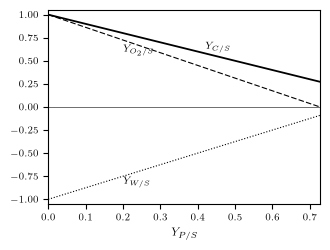

In [8]:
# part (c) -- the three yield factors against Y_P/S
YP = np.linspace(0.0, Y_max, 400)
YC = 1.0 - YP
YW = 1.25 * YP - 1.0
YO2 = 1.0 - 1.375 * YP
YO2_xi = np.array([f9.Y_O2_from_xi(Y_P_S=y) for y in YP])
print(f"  max |mass-balance route - Eq. 15.7-12 route| for Y_O2/S = "
      f"{np.max(np.abs(YO2 - YO2_xi)):.2e}")
assert np.max(np.abs(YO2 - YO2_xi)) < 1e-12
print(f"  at the second-law limit Y_P/S = {Y_max:.3f}:  Y_C/S = {YC[-1]:.3f}, "
      f"Y_W/S = {YW[-1]:+.3f}, Y_O2/S = {YO2[-1]:.4f}")
print("  -- the oxygen requirement goes to ZERO exactly at the limit, which is the")
print("  Y_O2/S >= 0 conclusion of Eq. 15.7-24 seen from the other side")

fig, ax = plt.subplots(figsize=(FIG_W, 2.6))
ax.plot(YP, YC, "k", lw=1.3)
ax.plot(YP, YO2, "k", lw=0.8, ls=(0, (5, 2)))
ax.plot(YP, YW, "k", lw=0.8, ls=(0, (1, 1.6)))
ax.axhline(0.0, color="k", lw=0.4)
ax.text(0.42, 0.63, r"$Y_{C/S}$", fontsize=7)
ax.text(0.20, 0.60, r"$Y_{O_2/S}$", fontsize=7)
ax.text(0.20, -0.83, r"$Y_{W/S}$", fontsize=7)
ax.set_xlabel(r"$Y_{P/S}$", fontsize=8)
ax.set_xlim(0, Y_max)
ax.set_ylim(-1.05, 1.05)
ax.tick_params(labelsize=7)
fig.tight_layout()
fig.savefig("pdf/c15f016.pdf", dpi=300, bbox_inches="tight")
print("\n  wrote pdf/c15f016.pdf  (Figure 15.7-2)")

  Y_Q/S = 110.9 (5.5 Y_P/S - 4):  -443.6 kJ at Y_P/S = 0, +0.00 kJ at the limit
  and with the MEASURED heats instead: -21.6 kJ at the limit, -469.0 at Y_P/S = 0

  wrote pdf/c15f017.pdf  (Figure 15.7-3)
  The printed Figure 15.7-3 carries a vertical axis running -200 at the top to
  -700 at the bottom. Eq. 15.7-11 on this fermentation gives -443.6 kJ at
  Y_P/S = 0 and 0 at the limit, so the whole curve lies ABOVE the
  printed axis. Using the measured heats instead moves it to -469 .. -22, still not -700.


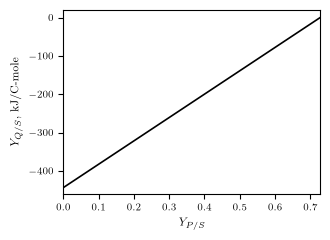

In [9]:
# part (d) -- the heat load along the same axis
YQ = 110.9 * (butanediol.xi * YP - xylose.xi)
print(f"  Y_Q/S = 110.9 (5.5 Y_P/S - 4):  {YQ[0]:+.1f} kJ at Y_P/S = 0, "
      f"{YQ[-1]:+.2f} kJ at the limit")
print(f"  and with the MEASURED heats instead: "
      f"{2461.0 / 4 * Y_max - 2345.2 / 5:+.1f} kJ at the limit, "
      f"{-2345.2 / 5:+.1f} at Y_P/S = 0")

fig, ax = plt.subplots(figsize=(FIG_W, 2.5))
ax.plot(YP, YQ, "k", lw=1.2)
ax.set_xlabel(r"$Y_{P/S}$", fontsize=8)
ax.set_ylabel(r"$Y_{Q/S}$, kJ/C-mole", fontsize=8)
ax.set_xlim(0, Y_max)
ax.set_ylim(-460, 20)
ax.tick_params(labelsize=7)
fig.tight_layout()
fig.savefig("pdf/c15f017.pdf", dpi=300, bbox_inches="tight")
print("\n  wrote pdf/c15f017.pdf  (Figure 15.7-3)")
print(f"  The printed Figure 15.7-3 carries a vertical axis running -200 at the top to")
print(f"  -700 at the bottom. Eq. 15.7-11 on this fermentation gives {YQ[0]:.1f} kJ at")
print(f"  Y_P/S = 0 and {YQ[-1]:.0f} at the limit, so the whole curve lies ABOVE the")
print(f"  printed axis. Using the measured heats instead moves it to "
      f"{-2345.2 / 5:.0f} .. {2461.0 / 4 * Y_max - 2345.2 / 5:.0f}, still not -700.")

## Illustration 15.7-10 — choosing a substrate

An unspecified substrate characterized only by $\xi_S$, ammonia as the nitrogen source, biomass and
CO$_2$ as the only products. Four constraints on $Y_{B/S}$, drawn on one pair of axes:

| constraint | line |
|---|---|
| carbon | $Y_{B/S}=1-Y_{C/S}\le 1$ |
| nitrogen source limited | $Y_{B/S}=5\,Y_{N/S}$ (horizontal) |
| oxygen limited (Eq. 15.7-12) | $Y_{B/S}=(\xi_S-4Y_{O_2/S})/4.2$ |
| second law (Eq. 15.7-19) | $Y_{B/S}=0.2439\,\xi_S$ |
| heat load (Eq. 15.7-11 + N balance) | $Y_{Q/S}=462.7\,Y_{B/S}-110.9\,\xi_S$ |

The section's own observation is that the second-law line and the anaerobic ($Y_{O_2/S}=0$) line are
almost the same — 0.2439 against 0.2381 — and differ *only* because ammonia is not exactly on the
regularity correlation. That is checked below rather than asserted: setting ammonia's
$\Delta_cG$ to $112\xi$ makes the two lines identical.

In [10]:
XI = np.linspace(0.0, 8.0, 200)
# A stand-in substrate whose only property is its degree of reduction. `CMole("C")`
# has xi = 4 by Eq. 15.7-9, so the second-law yield it returns has to be divided
# through by that xi to get the SLOPE of the line against xi_S.
f10 = Fermentation(substrate=CMole("C", name="unspecified substrate"),
                   biomass=BIOMASS_ROELS, nitrogen=ammonia)

# The oxygen line, with the nitrogen balance folded in.
coef_O2 = 4.2                       # xi_B - N_B xi_N = 4.8 - 0.2 x 3
print(f"  oxygen line:      Y_B/S = (xi_S - 4 Y_O2/S)/{coef_O2:g}")
print(f"  anaerobic line:   Y_B/S = xi_S/{coef_O2:g} = {1 / coef_O2:.4f} xi_S"
      f"      printed 0.2381")

# The second-law line, from the module.
slope_2nd = f10.max_biomass_yield() / f10.substrate.xi
print(f"  second-law line:  Y_B/S = {slope_2nd:.4f} xi_S            printed 0.2439")
assert abs(slope_2nd - 0.2439) < 5e-5

ammonia_regular = CMole("NH3", name="ammonia, on the regularity line",
                        dcG=112.0 * 3, dcH=110.9 * 3)
f10r = Fermentation(substrate=CMole("C"), biomass=BIOMASS_ROELS,
                    nitrogen=ammonia_regular)
print(f"  the same with ammonia forced onto 112 xi: "
      f"{f10r.max_biomass_yield() / f10r.substrate.xi:.4f} xi_S")
print(f"  and 1/4.2 = {1 / 4.2:.4f}. So the gap between the two lines IS the ammonia")
print(f"  datum's departure from the correlation, exactly as the section says.")

# The heat-load line.
coef_Q = REGULARITY_H * BIOMASS_ROELS.xi - ammonia.combustion_H() * BIOMASS_ROELS.N
print(f"\n  heat line:        Y_Q/S = {coef_Q:.1f} Y_B/S - 110.9 xi_S"
      f"      printed 462.7")
assert abs(coef_Q - 462.7) < 0.1

  oxygen line:      Y_B/S = (xi_S - 4 Y_O2/S)/4.2
  anaerobic line:   Y_B/S = xi_S/4.2 = 0.2381 xi_S      printed 0.2381
  second-law line:  Y_B/S = 0.2439 xi_S            printed 0.2439
  the same with ammonia forced onto 112 xi: 0.2381 xi_S
  and 1/4.2 = 0.2381. So the gap between the two lines IS the ammonia
  datum's departure from the correlation, exactly as the section says.

  heat line:        Y_Q/S = 462.7 Y_B/S - 110.9 xi_S      printed 462.7


  wrote pdf/c15uf007.pdf
  This is the figure the 6e source currently points at c15f007.eps for --
  which is Figure 15.3-2's single-site binding isotherm. The art it wants is
  c15uf007, which exists in the art set and is inserted nowhere.

  reading the figure: three of the families are CEILINGS on Y_B/S -- carbon,
  the nitrogen source, and the second law -- and the achievable yield is the
  lowest of them. The Y_O2/S family is not a ceiling; it says how much oxygen
  the chosen point needs, and Y_O2/S < 0 is the second-law violation itself.
    xi_S = 2:  carbon 1.000,  N source at Y_N/S = 0.1 0.500,  second law 0.488
              -> limited by second law at Y_B/S = 0.488, which needs Y_O2/S = -0.012
    xi_S = 4:  carbon 1.000,  N source at Y_N/S = 0.1 0.500,  second law 0.976
              -> limited by N source at Y_N/S = 0.1 at Y_B/S = 0.500, which needs Y_O2/S = 0.475
    xi_S = 6:  carbon 1.000,  N source at Y_N/S = 0.1 0.500,  second law 1.463
              -> limited by N 

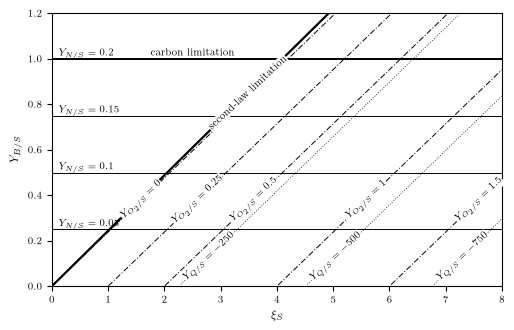

In [11]:
fig, ax = plt.subplots(figsize=(1.55 * FIG_W, 3.4))
XLIM, YLIM = 8.0, 1.2
ROT = 43            # the four families are all within a degree of this slope on these
                    # axes, so one rotation serves every inline label
BOX = dict(facecolor="white", edgecolor="none", pad=0.6)


def inline(x, y, text, rotation=ROT):
    """A label written ON its own curve, with the curve masked behind it."""
    ax.text(x, y, text, fontsize=7, rotation=rotation, rotation_mode="anchor",
            ha="center", va="center", bbox=BOX)


# nitrogen-source limitation: horizontal, Y_B/S = 5 Y_N/S. Labels go at the LEFT edge,
# which is the only part of the plot no other family crosses.
for YN_line in (0.05, 0.10, 0.15, 0.20):
    y = 5 * YN_line
    ax.plot([0, XLIM], [y, y], "k", lw=0.7)
    ax.text(0.12, y + 0.015, rf"$Y_{{N/S}}={YN_line:g}$", fontsize=7, ha="left")

# carbon limitation
ax.plot([0, XLIM], [1.0, 1.0], "k", lw=1.4)
ax.text(2.5, 1.015, "carbon limitation", fontsize=7, ha="center")

# oxygen limitation, Eq. 15.7-12, labeled on the curve at Y_B/S = 0.38
for YO in (0.0, 0.25, 0.5, 1.0, 1.5):
    y = (XI - 4 * YO) / coef_O2
    m = (y >= 0) & (y <= YLIM)
    ax.plot(XI[m], y[m], "k", lw=0.7, ls=(0, (6, 2, 1, 2)))
    x_lab = 4 * YO + coef_O2 * 0.38
    if x_lab < XLIM - 0.4:
        inline(x_lab, 0.38, rf"$Y_{{O_2/S}}={YO:g}$")

# heat load, Eq. 15.7-11 with the nitrogen balance folded in, labeled at Y_B/S = 0.13
for YQ_line in (-250.0, -500.0, -750.0):
    y = (YQ_line + REGULARITY_H * XI) / coef_Q
    m = (y >= 0) & (y <= YLIM)
    ax.plot(XI[m], y[m], "k", lw=0.6, ls=(0, (1, 2)))
    x_lab = (coef_Q * 0.13 - YQ_line) / REGULARITY_H
    if x_lab < XLIM - 0.4:
        inline(x_lab, 0.13, rf"$Y_{{Q/S}}={YQ_line:g}$")

# the second-law line, the heaviest stroke on the figure
ax.plot(XI, slope_2nd * XI, "k", lw=1.6)
inline(0.85 / slope_2nd, 0.85, "second-law limitation")

ax.set_xlabel(r"$\xi_S$", fontsize=8)
ax.set_ylabel(r"$Y_{B/S}$", fontsize=8)
ax.set_xlim(0, XLIM)
ax.set_ylim(0, YLIM)
ax.tick_params(labelsize=7)
fig.tight_layout()
fig.savefig("pdf/c15uf007.pdf", dpi=300, bbox_inches="tight")
print("  wrote pdf/c15uf007.pdf")
print("  This is the figure the 6e source currently points at c15f007.eps for --")
print("  which is Figure 15.3-2's single-site binding isotherm. The art it wants is")
print("  c15uf007, which exists in the art set and is inserted nowhere.")
print()
print("  reading the figure: three of the families are CEILINGS on Y_B/S -- carbon,")
print("  the nitrogen source, and the second law -- and the achievable yield is the")
print("  lowest of them. The Y_O2/S family is not a ceiling; it says how much oxygen")
print("  the chosen point needs, and Y_O2/S < 0 is the second-law violation itself.")
for xs in (2.0, 4.0, 6.0):
    ceilings = {"carbon": 1.0, "N source at Y_N/S = 0.1": 0.5,
                "second law": slope_2nd * xs}
    who = min(ceilings, key=ceilings.get)
    YB_max = ceilings[who]
    print(f"    xi_S = {xs:.0f}:  " + ",  ".join(f"{k} {v:.3f}" for k, v in ceilings.items())
          + f"\n              -> limited by {who} at Y_B/S = {YB_max:.3f}, which needs "
            f"Y_O2/S = {(xs - coef_O2 * YB_max) / 4:.3f}")

## Illustration 15.7-11 — a complete analysis, on measured data

von Stockar and Birou's fermentation of glucose by *K. fragilis* at 25 $^\circ$C: $Y_{B/S}=0.572$,
$Y_{CO_2/S}=0.398$, and a measured heat load of $-180.9$ kJ per C-mole. Biomass
$\mathrm{CH_{1.75}O_{0.52}N_{0.15}}$.

This is the only place in Sec. 15.7 where the heat load is **measured** rather than computed, so it
is the section's one real test — and the balances land within 1.3 percent of it.

In [12]:
kfragilis = CMole("CH1.75O0.52N0.15", name="K. fragilis biomass")
f11 = Fermentation(substrate=glucose, biomass=kfragilis, nitrogen=ammonia,
                   product=ethanol, T=T25)
YB11, YC11, YQ_MEASURED = 0.572, 0.398, -180.9

print(f"  xi(biomass) = {kfragilis.xi:.2f}      printed 4.71")
print(f"  dcG = 112   x {kfragilis.xi:.2f} = {kfragilis.combustion_G():.1f}   printed 527.5")
print(f"  dcH = 110.9 x {kfragilis.xi:.2f} = {kfragilis.combustion_H():.1f}   printed 522.3")

s11 = f11.solve(Y_B_S=YB11, Y_C_S=YC11)
print(f"\n  (a) Y_P/S  = {s11['Y_P_S']:.4f}      printed 0.030")
print(f"  (b) Y_N/S  = {s11['Y_N_S']:.4f}      printed 0.086")
print(f"  (c) Y_O2/S = {s11['Y_O2_S']:.4f}      printed 0.346")
YQ = f11.heat_load(s11["Y_B_S"], s11["Y_P_S"], s11["Y_N_S"])
print(f"  (d) Y_Q/S  = {YQ:.1f} kJ/C-mole   printed -178.5,  MEASURED {YQ_MEASURED}")
print(f"      the balance is {100 * (YQ / YQ_MEASURED - 1):+.1f} percent from the "
      f"measurement")
Sgen = f11.entropy_generated(s11["Y_B_S"], s11["Y_P_S"], s11["Y_N_S"])
print(f"  (e) S_gen  = {Sgen:.4f} kJ/(C-mol K)   printed 0.640")
for got, want in ((s11["Y_P_S"], 0.030), (s11["Y_N_S"], 0.086),
                  (s11["Y_O2_S"], 0.346), (YQ, -178.5), (Sgen, 0.640)):
    assert abs(got - want) < 0.06 * max(abs(want), 1e-3) + 1e-3, (got, want)

print(f"\n  and the linear approximation, Eq. 15.7-25:")
print(f"  Y_Q/S = -443.6 x {s11['Y_O2_S']:.4f} = "
      f"{-443.6 * s11['Y_O2_S']:.1f} kJ      printed -153.5")

  xi(biomass) = 4.71      printed 4.71
  dcG = 112   x 4.71 = 527.5   printed 527.5
  dcH = 110.9 x 4.71 = 522.3   printed 522.3

  (a) Y_P/S  = 0.0300      printed 0.030
  (b) Y_N/S  = 0.0858      printed 0.086
  (c) Y_O2/S = 0.3458      printed 0.346
  (d) Y_Q/S  = -178.4 kJ/C-mole   printed -178.5,  MEASURED -180.9
      the balance is -1.4 percent from the measurement
  (e) S_gen  = 0.6399 kJ/(C-mol K)   printed 0.640

  and the linear approximation, Eq. 15.7-25:
  Y_Q/S = -443.6 x 0.3458 = -153.4 kJ      printed -153.5


The printed part (e) writes the last term of the entropy balance as
$0.030\times684.5$. 684.5 is ethanol's $\Delta_cH$; its $\Delta_cG$ is 659.5, and the entropy balance
needs the Gibbs energy. The printed **answer** 0.640 is the one 659.5 gives, so the display is the
slip, not the arithmetic — and the two have to be separated by running both, not by guessing.

In [13]:
num_G = (glucose.combustion_G() + s11["Y_N_S"] * ammonia.combustion_G()
         - YB11 * kfragilis.combustion_G() - s11["Y_P_S"] * ethanol.combustion_G())
num_H = (glucose.combustion_G() + s11["Y_N_S"] * ammonia.combustion_G()
         - YB11 * kfragilis.combustion_G() - s11["Y_P_S"] * ethanol.combustion_H())
print(f"  with dcG(ethanol) = 659.5:  S_gen = {num_G / T25:.4f}   <- printed answer 0.640")
print(f"  with dcH(ethanol) = 684.5:  S_gen = {num_H / T25:.4f}")
print("\n  Eq. 15.7-26b, the approximate route -- and a units check it does not pass:")
print(f"  as printed, (xi_S + xi_N Y_N/S - xi_B Y_B/S - xi_P Y_P/S)/T = 4 Y_O2/S / T")
print(f"           = {4 * s11['Y_O2_S'] / T25:.4f}  per kelvin -- the numerator is a")
print(f"  DEGREE OF REDUCTION, which is dimensionless, so this cannot be an entropy.")
print(f"  Multiplying by the 112 kJ/C-mole of Eq. 15.7-10, as Eq. 15.7-18 requires:")
print(f"    112 x 4 Y_O2/S / T   = {REGULARITY_G * 4 * s11['Y_O2_S'] / T25:.4f} kJ/(C-mol K)")
print(f"    -(112/110.9) Y_Q/S / T = "
      f"{-(REGULARITY_G / REGULARITY_H) * f11.heat_load_regularity(s11['Y_B_S'], s11['Y_P_S'], s11['Y_N_S']) / T25:.4f} kJ/(C-mol K)")
print(f"  against the exact {Sgen:.4f}. The regularity form is 19 percent low, because")
print("  this fermentation's glucose is 24 kJ/C-mole off the correlation.")

  with dcG(ethanol) = 659.5:  S_gen = 0.6399   <- printed answer 0.640
  with dcH(ethanol) = 684.5:  S_gen = 0.6374

  Eq. 15.7-26b, the approximate route -- and a units check it does not pass:
  as printed, (xi_S + xi_N Y_N/S - xi_B Y_B/S - xi_P Y_P/S)/T = 4 Y_O2/S / T
           = 0.0046  per kelvin -- the numerator is a
  DEGREE OF REDUCTION, which is dimensionless, so this cannot be an entropy.
  Multiplying by the 112 kJ/C-mole of Eq. 15.7-10, as Eq. 15.7-18 requires:
    112 x 4 Y_O2/S / T   = 0.5196 kJ/(C-mol K)
    -(112/110.9) Y_Q/S / T = 0.5196 kJ/(C-mol K)
  against the exact 0.6399. The regularity form is 19 percent low, because
  this fermentation's glucose is 24 kJ/C-mole off the correlation.


## Figure 15.7-5 — the same linear law, for animals

$$\text{metabolic rate}\ \left(\frac{\text{kJ}}{\text{day}}\right)
= 21\,800\times\text{oxygen consumption}\ \left(\frac{\text{m}^3}{\text{day}}\right)$$

Eq. 15.7-25 states that a fermenter releases 443.6 kJ per mole of oxygen consumed. At 1 bar and 25
$^\circ$C a cubic meter of oxygen is about 40 moles, so the fermenter's own constant, in the
animals' units, is about 18 000 kJ/m$^3$ — and warm-blooded mammals from a shrew to an elephant sit
at 21 800. Same law, six orders of magnitude of body weight, and no fermenter in sight.

The six measured points (Cooney *et al.* 1968) are **not in this notebook yet**; the section supplies
one of them in words, the average human male at 0.36 m$^3$/day.

  1 m3 of ideal gas at 25 C, 1 atm = 40.9 mol
  Eq. 15.7-25 in the animals' units: 443.6 x 40.9 = 18133 kJ/m3
  the mammalian correlation:                        21 800 kJ/m3
  ratio 1.20

  average human male, 0.36 m3/day  ->  7848 kJ/day = 1876 kcal/day      printed 7850, 1875



  wrote pdf/c15f018.pdf  (Figure 15.7-5, line and the one stated point)
  the shrew, cat, dog, horse and elephant come from Cooney, Wang and Mateles,
  Biotech. Bioeng. 11, 269 (1968) and are still to be added


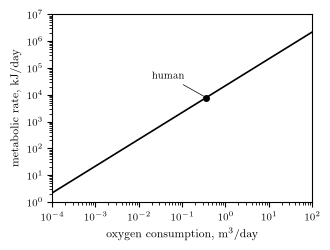

In [14]:
R_GAS, P_ATM = 8.314, 1.01325e5
mol_per_m3 = P_ATM / (R_GAS * T25)
print(f"  1 m3 of ideal gas at 25 C, 1 atm = {mol_per_m3:.1f} mol")
print(f"  Eq. 15.7-25 in the animals' units: 443.6 x {mol_per_m3:.1f} = "
      f"{443.6 * mol_per_m3:.0f} kJ/m3")
print(f"  the mammalian correlation:                        21 800 kJ/m3")
print(f"  ratio {21_800 / (443.6 * mol_per_m3):.2f}")

human_O2 = 0.36
print(f"\n  average human male, {human_O2} m3/day  ->  "
      f"{metabolic_rate(human_O2):.0f} kJ/day = "
      f"{metabolic_rate(human_O2) / 4.184:.0f} kcal/day      printed 7850, 1875")
assert abs(metabolic_rate(human_O2) - 7850) < 5

fig, ax = plt.subplots(figsize=(FIG_W, 2.6))
O2 = np.logspace(-4, 2, 200)
ax.loglog(O2, metabolic_rate(O2), "k", lw=1.2)
ax.plot([human_O2], [metabolic_rate(human_O2)], "ko", ms=4)
ax.annotate("human", xy=(human_O2, metabolic_rate(human_O2)), xytext=(0.02, 4e4),
            fontsize=7, arrowprops=dict(arrowstyle="-", lw=0.5))
ax.set_xlabel(r"oxygen consumption, m$^3$/day", fontsize=8)
ax.set_ylabel("metabolic rate, kJ/day", fontsize=8)
ax.set_xlim(1e-4, 1e2)
ax.set_ylim(1, 1e7)
ax.tick_params(labelsize=7)
fig.tight_layout()
fig.savefig("pdf/c15f018.pdf", dpi=300, bbox_inches="tight")
print("\n  wrote pdf/c15f018.pdf  (Figure 15.7-5, line and the one stated point)")
print("  the shrew, cat, dog, horse and elephant come from Cooney, Wang and Mateles,")
print("  Biotech. Bioeng. 11, 269 (1968) and are still to be added")

## What came out of this

| target | here | printed |
|---|---|---|
| 15.7-6, $\xi$ and $\Delta_cH$ of the biomass | 4.68, 519.0 | same |
| 15.7-6, $Y_{Q/S}$ measured / regularity | $-51.0$ / $-34.8$ kJ | same |
| 15.7-7, the two sides | 494.3 $\ge$ 420.6, 85.1 % | same |
| 15.7-7 Note, on $\xi$ alone | 4.1197 $>$ 3.8058, 92.4 % | same |
| 15.7-8, $Y_{Q/S}$ | $-13.5$ kJ | $-13.5$, then "6 x **14.5** = 81" |
| 15.7-8, the constraint | 489.7 $>$ 450.5, 92.0 % | 489.6 $>$ **450.2**, then 450.5 in the ratio |
| 15.7-9, $\xi_S/\xi_P$ | 0.7273 | 0.727 |
| 15.7-9, g per kg of xylose | 545 | 545 |
| 15.7-9, $Y_{O_2/S}$ at the limit | 0.0000 | — |
| 15.7-10, anaerobic line | 0.2381 $\xi_S$ | 0.2381 |
| 15.7-10, second-law line | 0.2439 $\xi_S$ | 0.2439 |
| 15.7-10, heat line | 462.7 | 462.7 |
| 15.7-11, all five parts | 0.030, 0.086, 0.346, $-178.4$, 0.640 | same |
| 15.7-11, $Y_{Q/S}$ against the measurement | $-178.4$ vs $-180.9$, 1.4 % | "not unreasonable" |
| Eq. 15.7-26b with the 112 restored | 0.5196 both ways | dimensionless as printed |
| Fig. 15.7-5, human | 7848 kJ/day, 1876 kcal | 7850, 1875 |

Five things the calculation found.

**Illustration 15.7-6's Solution line calls ammonia's heat of combustion 383.0 kJ/mol**; Table 15.7-2
gives 348.1, and only 348.1 reproduces the illustration's own $-51.0$ kJ.

**Illustration 15.7-8 prints "6 × 14.5 = 81"** where the heat load one line above is 13.5, and its
second-law display sums to 450.2 where the ratio line two clauses later uses 450.5. The 450.5 is
right.

**Illustration 15.7-11's part (e) multiplies the ethanol yield by 684.5**, which is ethanol's
$\Delta_cH$; the entropy balance needs $\Delta_cG=659.5$, and the printed answer 0.640 is the one
659.5 gives.

**Eq. 15.7-26b is dimensionally inconsistent.** Its numerator is
$\xi_S+\xi_NY_{N/S}-\xi_BY_{B/S}-\xi_PY_{P/S}$, which is dimensionless, so dividing by $T$ gives
per-kelvin rather than kJ/(C-mol K). It needs the 112 kJ/C-mole of Eq. 15.7-10 in front, exactly as
Eq. 15.7-18 carries it; with that factor both of its forms give 0.5196 kJ/(C-mol K) against
Eq. 15.7-26a's exact 0.6399.

**Figure 15.7-3's vertical axis cannot be right.** Its printed range is $-200$ to $-700$ kJ/C-mole,
and Eq. 15.7-11 on this fermentation runs from $-443.6$ kJ at $Y_{P/S}=0$ to zero at the second-law
limit. Substituting the measured heats of combustion moves the curve to $-469$ … $-22$, which does
not reach $-700$ either. The redrawn figure runs $-460$ to 0.

## Your turn

1. Eq. 15.7-25 states that $Y_{Q/S}=-443.6\,Y_{O_2/S}$ exactly, under the energy regularity assumption.
   Check it on Illustration 15.7-11, where measured heats are used for three of four species, and
   report the error. Then find the property of the substrate that controls how big that error is.
2. The second-law line in Illustration 15.7-10 is $Y_{B/S}=0.2439\,\xi_S$ and the anaerobic line is
   $0.2381\,\xi_S$. Redo both with a nitrogen source that is *not* nearly on the regularity line —
   glutamic acid, say, whose $\Delta_cG$ Table 15.7-2 gives — and report how far apart the two lines
   move. Which one moves?
3. For what range of $\xi_S$ is a fermentation to average biomass limited by carbon rather than by
   the second law? Read it off the figure, then get it exactly, and say what kind of substrate has a
   $\xi_S$ that large.
4. Illustration 15.7-9 gets a hard ceiling of 0.727 C-mole/C-mole for 2,3-butanediol from xylose.
   Recompute it with the *measured* Gibbs energies of combustion instead of $112\xi$ — you will need
   $\Delta_cG$ for both compounds, so start from the measured $\Delta_cH$ and estimate the entropy
   term. How much does the ceiling move, and is the engineering conclusion different?
5. Take Illustration 15.7-11's five answers and ask which of them the measured $Y_{Q/S}=-180.9$
   could have been used to *check* rather than to compare against. Reformulate the problem so that
   the measured heat load is an input and one of the yield factors is the output. Which factor is
   the heat load most sensitive to?
6. The mammalian correlation is 21 800 kJ per m$^3$ of oxygen and the fermenter constant is about
   18 000. Work out what the difference implies about the substrate an animal is metabolizing —
   what degree of reduction would close the gap? Is that a fat, a carbohydrate, or a protein?